<a href="https://colab.research.google.com/github/biswal-prem-5677/Coding-Journey/blob/main/ai/02_machine_learning/supervised_learning/computer_vision/plant_disease_classification/project_plant_disease_classification_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

STEP 1 — Install Kaggle

In [1]:
!pip install kaggle

STEP 2 — Upload Kaggle API Key

In [2]:
from google.colab import files

files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"prembiswal","key":"5c1ebf5c7bf05f1fc8bff1d0b30bbc0e"}'}

STEP 3 — Configure Kaggle

In [3]:
!mkdir -p ~/.kaggle

!cp kaggle.json ~/.kaggle/

!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets list

ref                                                                 title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
------------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
algozee/teenager-menthal-healy                                      Social Media Impact on Teen Mental Health                16190  2026-04-05 08:04:21.823000          33964        710                1  
laveshjadon/ai-impact-on-students                                   Impact of Ai on Students                               1187170  2026-05-10 23:12:10.070000           3110         70                1  
abdulmaliklodhra/social-media-addiction-and-mental-health-dataset   Social Media Addiction & Mental Health Dataset        13975225  2026-05-22 10:15:52.543000            916         28

STEP 4 — Download PlantVillage Dataset

In [5]:
!kaggle datasets download -d emmarex/plantdisease

Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
100% 658M/658M [00:03<00:00, 222MB/s]



STEP 5 — Unzip Dataset

In [6]:
!unzip plantdisease.zip

Streaming output truncated to the last 5000 lines.
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08c033bd-fbc3-445a-88d1-1863070e52ce___YLCV_GCREC 2872.JPG  
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08dd176c-e9d9-4746-92c3-fa8dc9074347___UF.GRC_YLCV_Lab 03057.JPG  
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08f78a80-46f5-45a6-937c-4d05d61c08c2___UF.GRC_YLCV_Lab 01895.JPG  
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/0903aa95-6e8a-4abd-a003-126fcd9a5493___YLCV_GCREC 2806.JPG  
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/0911d416-d73d-4c2a-8e45-207a7ceb7c9a___YLCV_GCREC 2773.JPG  
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/09188838-cc89-4925-94c5-d9563c4cb4bf___UF.GRC_YLCV_Lab 02974.JPG  
  inflating: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/0922e026-b563-438d-b9ed-74

STEP 6 — Import Libraries

In [7]:
import numpy as np

import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.preprocessing.image import (
    ImageDataGenerator
)

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Dense,
    Flatten,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

STEP 7 — Dataset Paths

In [8]:
train_dir = "/content/PlantVillage"

STEP 8 — Image Preprocessing

In [9]:
train_datagen = ImageDataGenerator(

    rescale=1./255,

    validation_split=0.2,

    rotation_range=20,

    zoom_range=0.2,

    horizontal_flip=True
)

STEP 9 — Create Training Data

In [10]:
train_data = train_datagen.flow_from_directory(

    train_dir,

    target_size=(128, 128),

    batch_size=32,

    class_mode="categorical",

    subset="training"
)

Found 16516 images belonging to 15 classes.


STEP 10 — Create Validation Data

In [11]:
val_data = train_datagen.flow_from_directory(

    train_dir,

    target_size=(128, 128),

    batch_size=32,

    class_mode="categorical",

    subset="validation"
)

Found 4122 images belonging to 15 classes.


STEP 11 — Visualize Agriculture Images

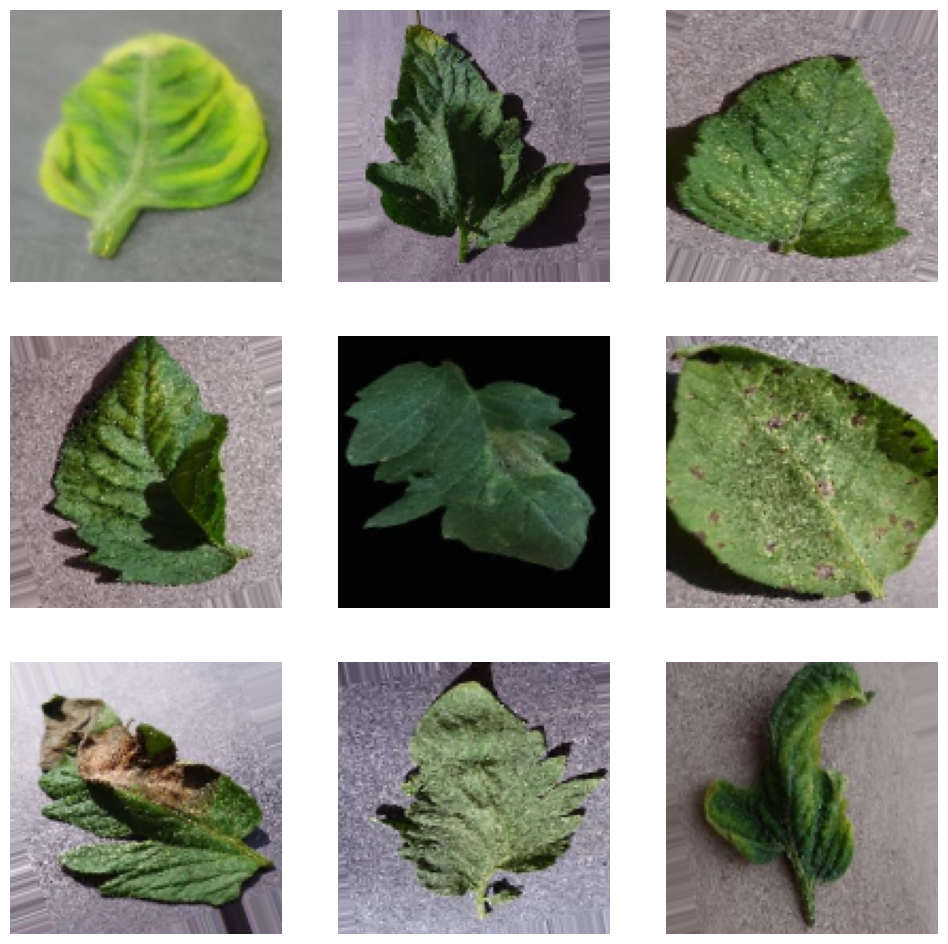

In [12]:
images, labels = next(train_data)

plt.figure(figsize=(12, 12))

for i in range(9):

    plt.subplot(3, 3, i+1)

    plt.imshow(images[i])

    plt.axis("off")

plt.show()

STEP 12 — Build CNN Model

In [13]:
model = Sequential()

# ====================================================
# BLOCK 1
# ====================================================

model.add(
    Conv2D(
        32,
        (3, 3),
        activation="relu",
        input_shape=(128, 128, 3)
    )
)

model.add(BatchNormalization())

model.add(MaxPooling2D((2, 2)))

# ====================================================
# BLOCK 2
# ====================================================

model.add(
    Conv2D(
        64,
        (3, 3),
        activation="relu"
    )
)

model.add(BatchNormalization())

model.add(MaxPooling2D((2, 2)))

# ====================================================
# BLOCK 3
# ====================================================

model.add(
    Conv2D(
        128,
        (3, 3),
        activation="relu"
    )
)

model.add(BatchNormalization())

model.add(MaxPooling2D((2, 2)))

# ====================================================
# FLATTEN
# ====================================================

model.add(Flatten())

# ====================================================
# DENSE
# ====================================================

model.add(
    Dense(
        256,
        activation="relu"
    )
)

model.add(Dropout(0.5))

# ====================================================
# OUTPUT
# ====================================================

model.add(
    Dense(
        train_data.num_classes,
        activation="softmax"
    )
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


STEP 13 — Compile Model

In [14]:
model.compile(

    optimizer="adam",

    loss="categorical_crossentropy",

    metrics=["accuracy"]
)

STEP 14 — Configure Callbacks

In [15]:
early_stop = EarlyStopping(

    monitor="val_loss",

    patience=5,

    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=3
)

STEP 15 — Train CNN

In [16]:
history = model.fit(

    train_data,

    validation_data=val_data,

    epochs=15,

    callbacks=[
        early_stop,
        reduce_lr
    ]
)

Epoch 1/15
517/517 ━━━━━━━━━━━━━━━━━━━━ 119s 215ms/step - accuracy: 0.3823 - loss: 2.3065 - val_accuracy: 0.3493 - val_loss: 3.0998 - learning_rate: 0.0010
Epoch 2/15
517/517 ━━━━━━━━━━━━━━━━━━━━ 103s 199ms/step - accuracy: 0.4903 - loss: 1.6446 - val_accuracy: 0.4571 - val_loss: 1.7739 - learning_rate: 0.0010
Epoch 3/15
517/517 ━━━━━━━━━━━━━━━━━━━━ 106s 205ms/step - accuracy: 0.5388 - loss: 1.4633 - val_accuracy: 0.5764 - val_loss: 1.3624 - learning_rate: 0.0010
Epoch 4/15
517/517 ━━━━━━━━━━━━━━━━━━━━ 105s 204ms/step - accuracy: 0.5854 - loss: 1.2842 - val_accuracy: 0.6739 - val_loss: 1.0467 - learning_rate: 0.0010
Epoch 5/15
517/517 ━━━━━━━━━━━━━━━━━━━━ 104s 202ms/step - accuracy: 0.6188 - loss: 1.1639 - val_accuracy: 0.6376 - val_loss: 1.3270 - learning_rate: 0.0010
Epoch 6/15
517/517 ━━━━━━━━━━━━━━━━━━━━ 105s 203ms/step - accuracy: 0.6482 - loss: 1.0590 - val_accuracy: 0.6269 - val_loss: 1.6927 - learning_rate: 0.0010
Epoch 7/15
517/517 ━━━━━━━━━━━━━━━━━━━━ 104s 202ms/step - accura

STEP 16 — Evaluate Model

In [17]:
loss, accuracy = model.evaluate(
    val_data
)

print("Validation Accuracy:", accuracy)

129/129 ━━━━━━━━━━━━━━━━━━━━ 20s 154ms/step - accuracy: 0.9304 - loss: 0.2534
Validation Accuracy: 0.9303736090660095


STEP 17 — Plot Accuracy Curves

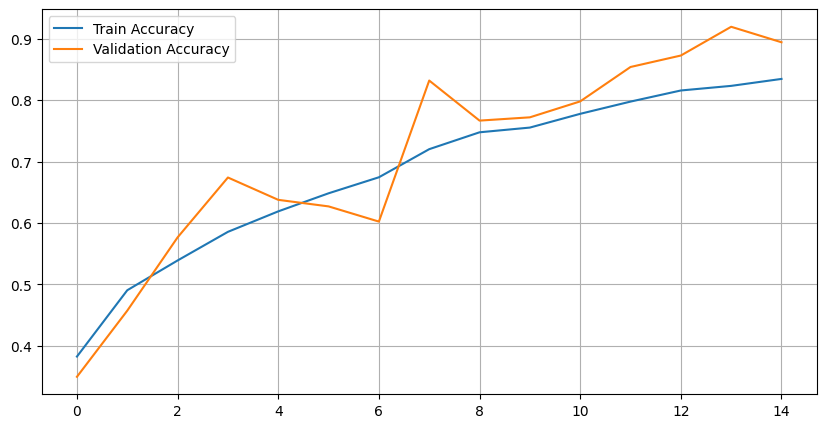

In [18]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["accuracy"],
    label="Train Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.legend()

plt.grid(True)

plt.show()

STEP 18 — Plot Loss Curves

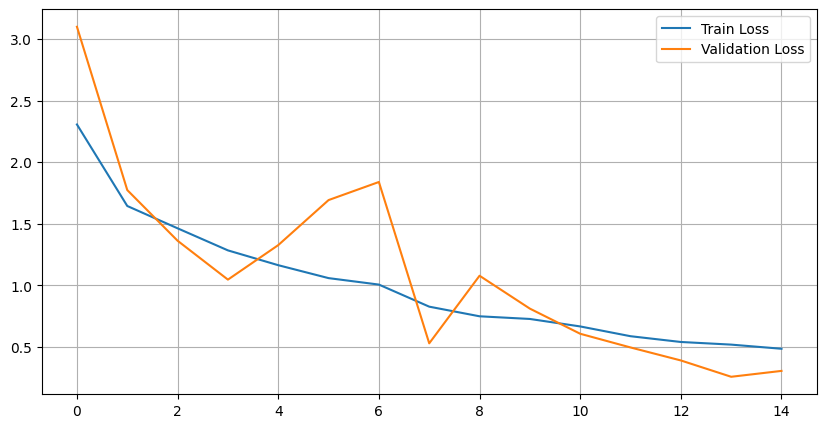

In [19]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    label="Train Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.legend()

plt.grid(True)

plt.show()

STEP 19 — Predict New Crop Image

In [20]:
from google.colab import files

uploaded = files.upload()

Check Dataset Classes

In [21]:
import os

dataset_path = "/content/PlantVillage"

classes = os.listdir(dataset_path)

print(classes)

['Tomato_Leaf_Mold', 'Potato___Late_blight', 'Tomato_healthy', 'Pepper__bell___Bacterial_spot', 'Tomato_Bacterial_spot', 'Tomato__Target_Spot', 'Pepper__bell___healthy', 'Tomato_Septoria_leaf_spot', 'Tomato__Tomato_mosaic_virus', 'Tomato_Late_blight', 'Potato___Early_blight', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato_Early_blight', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Potato___healthy']


Show Available Images

In [22]:
sample_class = classes[0]

sample_path = os.path.join(
    dataset_path,
    sample_class
)

images = os.listdir(sample_path)

print(images[:10])

['755296b4-fa21-4ec5-b912-bd85b2897a01___Crnl_L.Mold 8630.JPG', 'bb7c7fce-4601-43b6-b396-4f78ca7dd44c___Crnl_L.Mold 9013.JPG', '3dde4593-cc1e-4d3e-8cb4-d1a87f9f5b8c___Crnl_L.Mold 8740.JPG', 'bb98de22-463a-4ad2-8ad1-e65d1ea463c8___Crnl_L.Mold 7160.JPG', '51cb012e-4646-447c-b63f-9084a370b781___Crnl_L.Mold 6916.JPG', '8fcfbfee-f57a-49f7-9f68-19b4b1d5ca98___Crnl_L.Mold 6498.JPG', '306d3e00-d180-4645-9858-b22e3a292554___Crnl_L.Mold 6627.JPG', '4163864b-4d3b-4b6e-8174-e26b4dfc0a86___Crnl_L.Mold 8943.JPG', '4badfb88-91f8-49e0-baad-553c18b6bede___Crnl_L.Mold 6904.JPG', '6911d2dc-3f23-4a99-bf13-69a61f83585c___Crnl_L.Mold 8786.JPG']


Display Random Image

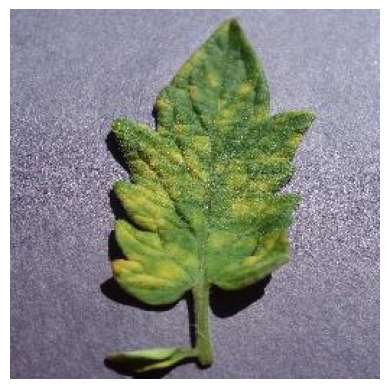

In [23]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img_path = os.path.join(
    sample_path,
    images[0]
)

img = mpimg.imread(img_path)

plt.imshow(img)

plt.axis("off")

plt.show()

EASIER METHOD — Direct Prediction Without Upload

In [24]:
import random

# Random class
random_class = random.choice(classes)

# Random image
random_image = random.choice(
    os.listdir(
        os.path.join(
            dataset_path,
            random_class
        )
    )
)

img_path = os.path.join(
    dataset_path,
    random_class,
    random_image
)

print(img_path)

/content/PlantVillage/Tomato_Bacterial_spot/807ff772-48f7-4e2e-b4ea-e05ce327a9a4___GCREC_Bact.Sp 6213.JPG


Load Random Dataset Image

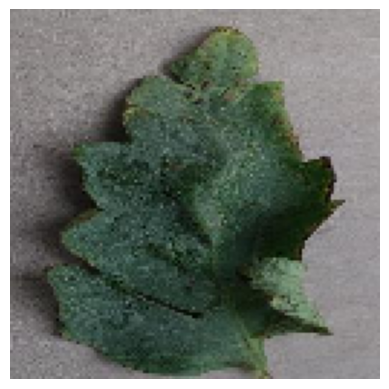

In [25]:
from tensorflow.keras.preprocessing import image

img = image.load_img(
    img_path,
    target_size=(128, 128)
)

plt.imshow(img)

plt.axis("off")

plt.show()

Predict Directly

In [26]:
img_array = image.img_to_array(img)

img_array = img_array / 255.0

img_array = np.expand_dims(
    img_array,
    axis=0
)

prediction = model.predict(
    img_array
)

predicted_class = np.argmax(
    prediction
)

class_names = list(
    train_data.class_indices.keys()
)

print(
    "Predicted Disease:",
    class_names[predicted_class]
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 791ms/step
Predicted Disease: Tomato_Bacterial_spot


Confusion Matrix

129/129 ━━━━━━━━━━━━━━━━━━━━ 31s 225ms/step


<Figure size 1200x1200 with 0 Axes>

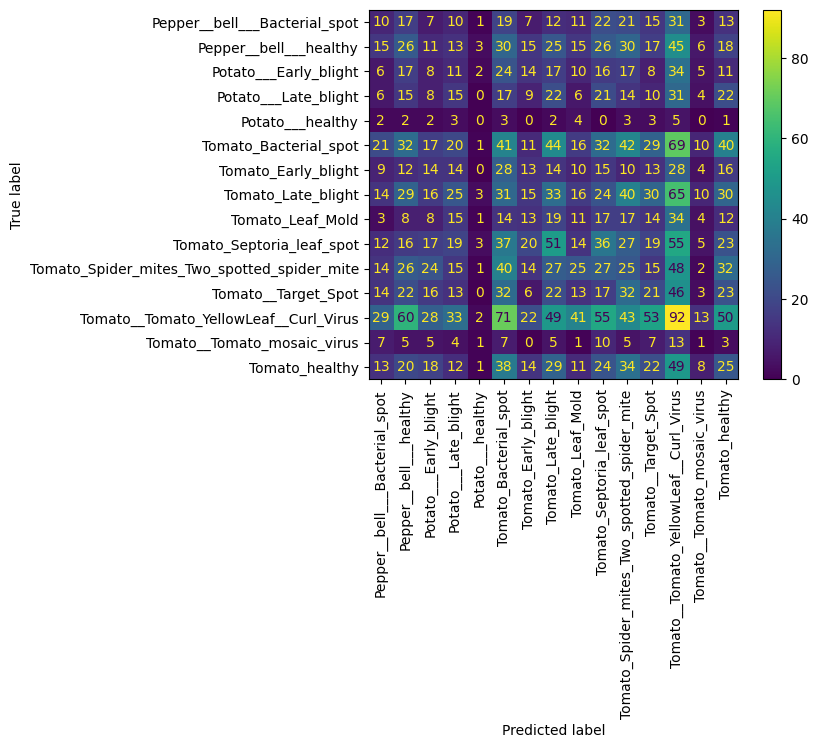

In [27]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

# Predictions
pred_probs = model.predict(val_data)

pred_classes = np.argmax(
    pred_probs,
    axis=1
)

true_classes = val_data.classes

# Confusion Matrix
cm = confusion_matrix(
    true_classes,
    pred_classes
)

# Plot
plt.figure(figsize=(12, 12))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=val_data.class_indices.keys()
)

disp.plot(
    xticks_rotation=90
)

plt.show()

Classification Report

In [28]:
from sklearn.metrics import classification_report

print(

    classification_report(

        true_classes,

        pred_classes,

        target_names=list(
            val_data.class_indices.keys()
        )
    )
)

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.06      0.05      0.05       199
                     Pepper__bell___healthy       0.08      0.09      0.09       295
                      Potato___Early_blight       0.04      0.04      0.04       200
                       Potato___Late_blight       0.07      0.07      0.07       200
                           Potato___healthy       0.00      0.00      0.00        30
                      Tomato_Bacterial_spot       0.09      0.10      0.10       425
                        Tomato_Early_blight       0.08      0.07      0.07       200
                         Tomato_Late_blight       0.09      0.09      0.09       381
                           Tomato_Leaf_Mold       0.05      0.06      0.06       190
                  Tomato_Septoria_leaf_spot       0.11      0.10      0.10       354
Tomato_Spider_mites_Two_spotted_spider_mite       0.07      0.07

Predict Multiple Images

In [29]:
import os
import random

dataset_path = "/content/plantvillage/PlantVillage"

classes = os.listdir(dataset_path)

# Random Class
random_class = random.choice(classes)

# Random Image
random_image = random.choice(

    os.listdir(
        os.path.join(
            dataset_path,
            random_class
        )
    )
)

img_path = os.path.join(
    dataset_path,
    random_class,
    random_image
)

print(img_path)

/content/plantvillage/PlantVillage/Tomato_Septoria_leaf_spot/45c5dbd2-e45d-438b-ae11-04e96417cb2f___Matt.S_CG 0666.JPG


Load + Predict

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


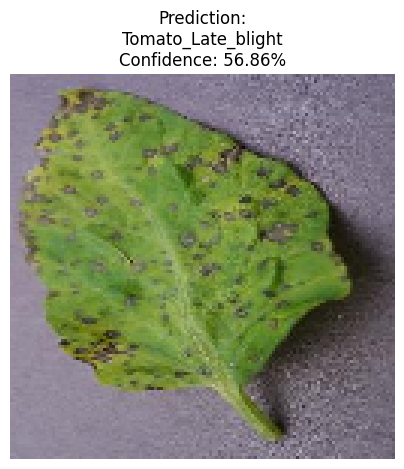

In [30]:
img = image.load_img(

    img_path,

    target_size=(128, 128)
)

img_array = image.img_to_array(img)

img_array = img_array / 255.0

img_array = np.expand_dims(
    img_array,
    axis=0
)

prediction = model.predict(
    img_array
)

predicted_class = np.argmax(
    prediction
)

confidence = np.max(prediction)

class_names = list(
    train_data.class_indices.keys()
)

plt.figure(figsize=(5, 5))

plt.imshow(img)

plt.axis("off")

plt.title(

    f"Prediction:\n"

    f"{class_names[predicted_class]}\n"

    f"Confidence: {confidence*100:.2f}%"
)

plt.show()

EfficientNetB0 Code

In [31]:
from tensorflow.keras.applications import EfficientNetB0

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D
)

Load Pretrained Model

In [32]:
base_model = EfficientNetB0(

    weights="imagenet",

    include_top=False,

    input_shape=(128, 128, 3)
)

base_model.trainable = False

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Build Transfer Learning Model

In [33]:
transfer_model = Sequential([

    base_model,

    GlobalAveragePooling2D(),

    Dense(
        256,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        train_data.num_classes,
        activation="softmax"
    )
])

Compile

In [34]:
transfer_model.compile(

    optimizer="adam",

    loss="categorical_crossentropy",

    metrics=["accuracy"]
)

Train

In [35]:
history_transfer = transfer_model.fit(

    train_data,

    validation_data=val_data,

    epochs=5
)

Epoch 1/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 185s 292ms/step - accuracy: 0.1450 - loss: 2.5974 - val_accuracy: 0.1555 - val_loss: 2.5727
Epoch 2/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 105s 203ms/step - accuracy: 0.1554 - loss: 2.5789 - val_accuracy: 0.1555 - val_loss: 2.5689
Epoch 3/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 103s 199ms/step - accuracy: 0.1554 - loss: 2.5763 - val_accuracy: 0.1555 - val_loss: 2.5646
Epoch 4/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 103s 200ms/step - accuracy: 0.1554 - loss: 2.5747 - val_accuracy: 0.1555 - val_loss: 2.5648
Epoch 5/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 103s 199ms/step - accuracy: 0.1554 - loss: 2.5731 - val_accuracy: 0.1555 - val_loss: 2.5654


Evaluate

In [36]:
loss, accuracy = transfer_model.evaluate(
    val_data
)

print(
    "Transfer Learning Accuracy:",
    accuracy
)

129/129 ━━━━━━━━━━━━━━━━━━━━ 21s 165ms/step - accuracy: 0.1555 - loss: 2.5653
Transfer Learning Accuracy: 0.15550702810287476


Save BEST MODEL

In [37]:
transfer_model.save(
    "best_crop_disease_model.keras"
)

Compare CNN vs EfficientNet

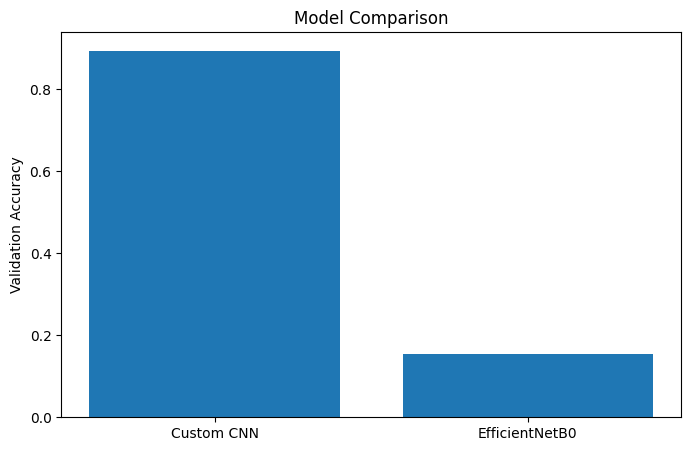

In [38]:
models = [
    "Custom CNN",
    "EfficientNetB0"
]

accuracies = [
    history.history["val_accuracy"][-1],
    history_transfer.history["val_accuracy"][-1]
]

plt.figure(figsize=(8, 5))

plt.bar(
    models,
    accuracies
)

plt.ylabel("Validation Accuracy")

plt.title("Model Comparison")

plt.show()